In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
df = pd.read_excel('../data_final_pakcoy.xlsx')

In [4]:
features = ['ph', 'water_temp', 'air_temp', 'humidity']

In [5]:
X = df[features].copy()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
wcss = []
sil_scores = []
K_range = range(2, 11)

In [8]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

Text(0.5, 1.0, 'Elbow Method')

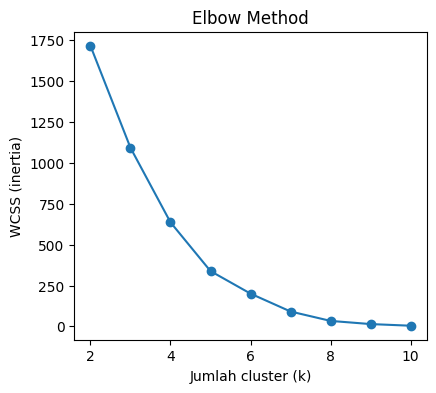

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), wcss, marker='o')
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method')

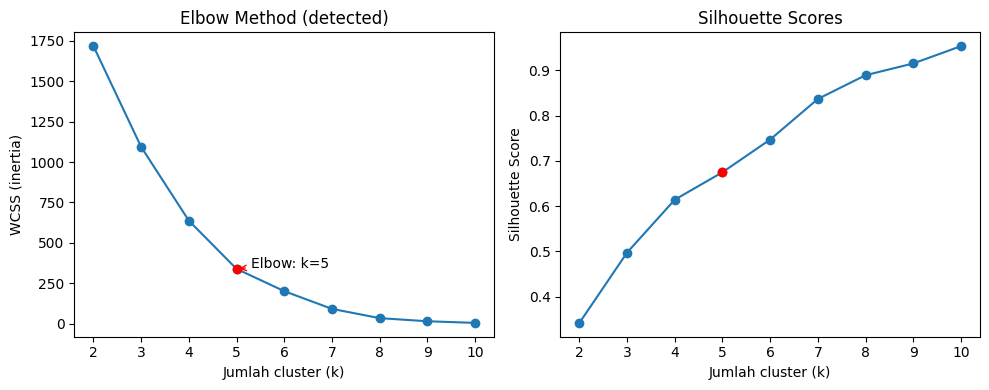

Jumlah cluster terpilih menurut elbow (sudut tajam): k = 5


In [10]:
def find_elbow_k(K_vals, wcss_vals):
    K = np.array(list(K_vals), dtype=float)
    W = np.array(wcss_vals, dtype=float)
    if K.size < 3:
        return int(K[0])
    # titik ujung garis
    x1, y1 = K[0], W[0]
    x2, y2 = K[-1], W[-1]
    # jarak perpendicular tiap titik ke garis (x1,y1)-(x2,y2)
    num = np.abs((y2 - y1)*K - (x2 - x1)*W + x2*y1 - y2*x1)
    den = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    dists = num / den
    idx = np.argmax(dists)
    return int(K[idx]), idx, dists

elbow_k, elbow_idx, dists = find_elbow_k(K_range, wcss)

# gambar ulang dengan penanda siku
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
Ks = list(K_range)
plt.plot(Ks, wcss, marker='o', label='WCSS')
plt.scatter([Ks[elbow_idx]], [wcss[elbow_idx]], color='red', zorder=5)
plt.annotate(f'Elbow: k={elbow_k}', xy=(Ks[elbow_idx], wcss[elbow_idx]),
             xytext=(Ks[elbow_idx]+0.3, wcss[elbow_idx]*1.02),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method (detected)')

plt.subplot(1,2,2)
plt.plot(Ks, sil_scores, marker='o', label='Silhouette')
plt.scatter([Ks[elbow_idx]], [sil_scores[elbow_idx]], color='red', zorder=5)
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()
plt.show()

print(f"Jumlah cluster terpilih menurut elbow (sudut tajam): k = {elbow_k}")

In [11]:
kmeans = KMeans(n_clusters=elbow_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

In [12]:
df.head()

,plant,day,leaf_count,plant_height,leaf_length,leaf_width,date,ph,ppm,water_temp,air_temp,humidity,cluster
0,1,0,4,3.36,2.38,1.08,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1
1,2,0,4,3.58,2.08,1.08,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1
2,3,0,4,4.12,2.10,1.26,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1
3,4,0,4,3.26,1.50,1.30,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1
4,5,0,4,2.02,1.30,1.00,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1


In [13]:
cluster_summary = df.groupby('cluster')['ppm'].agg(['count','mean','median','min','max']).reset_index()
cluster_summary = cluster_summary.rename(columns={'mean':'ppm_mean','median':'ppm_median'})
print("\nRingkasan PPM per cluster:")
display(cluster_summary)


Ringkasan PPM per cluster:


,cluster,count,ppm_mean,ppm_median,min,max
0,0,220,1045.538721,1006.480329,944.314898,1224.879329
1,1,55,888.677043,888.677043,888.677043,888.677043
2,2,165,1045.648150,1000.479329,907.181192,1229.283929
3,3,110,1150.479329,1150.479329,1100.479329,1200.479329
4,4,55,1100.679329,1100.679329,1100.679329,1100.679329


In [14]:
df['ppm_cluster_mean'] = df['cluster'].map(cluster_summary.set_index('cluster')['ppm_mean'])

In [15]:
df.head()

,plant,day,leaf_count,plant_height,leaf_length,leaf_width,date,ph,ppm,water_temp,air_temp,humidity,cluster,ppm_cluster_mean
0,1,0,4,3.36,2.38,1.08,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1,888.677043
1,2,0,4,3.58,2.08,1.08,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1,888.677043
2,3,0,4,4.12,2.10,1.26,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1,888.677043
3,4,0,4,3.26,1.50,1.30,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1,888.677043
4,5,0,4,2.02,1.30,1.00,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572,1,888.677043


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, df['ppm_cluster_mean'], test_size=0.3, random_state=42)

In [17]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [19]:
cv_scores = cross_val_score(reg, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\nCV R^2 scores (train): {np.round(cv_scores,3)}  |  mean = {cv_scores.mean():.3f}")
test_r2 = reg.score(X_test_scaled, y_test)
print(f"Test R^2 (regression on ppm_cluster_mean): {test_r2:.3f}")


CV R^2 scores (train): [1. 1. 1. 1. 1.]  |  mean = 1.000
Test R^2 (regression on ppm_cluster_mean): 1.000


In [20]:
df.loc[X_test.index, 'predicted_ppm'] = reg.predict(X_test_scaled)
preds_all = pd.Series(reg.predict(scaler.transform(X)), index=X.index)
df['predicted_ppm'] = df['predicted_ppm'].fillna(preds_all)

In [21]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

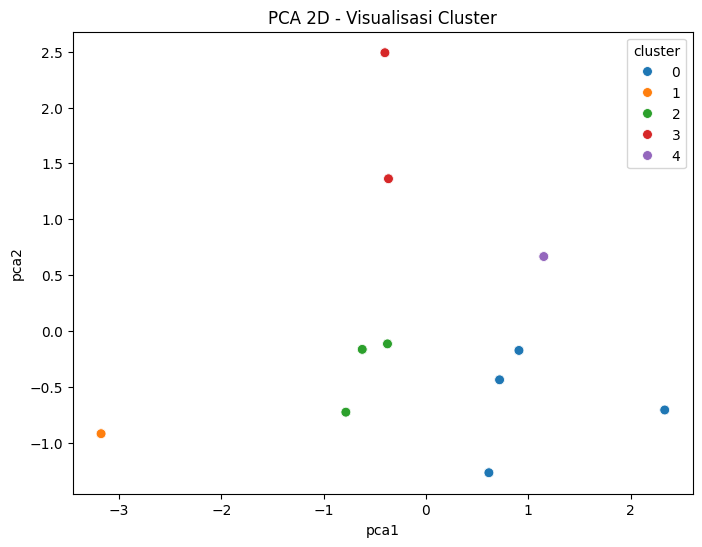

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10', s=50)
plt.title('PCA 2D - Visualisasi Cluster')
plt.legend(title='cluster')
plt.show()

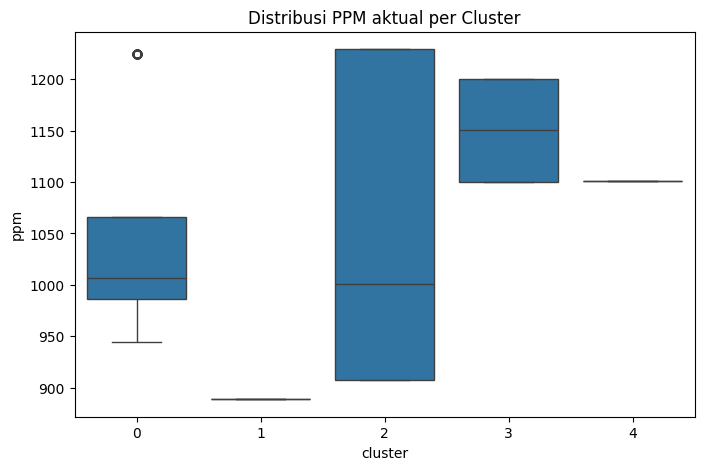

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='cluster', y='ppm')
plt.title('Distribusi PPM aktual per Cluster')
plt.show()

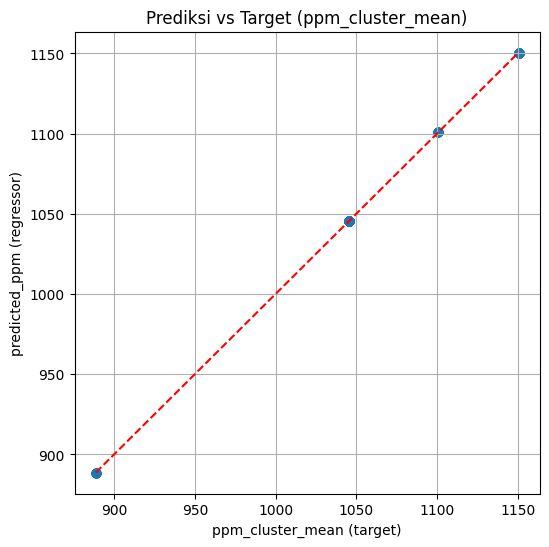

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(df['ppm_cluster_mean'], df['predicted_ppm'], alpha=0.6)
plt.plot([df['ppm_cluster_mean'].min(), df['ppm_cluster_mean'].max()],
         [df['ppm_cluster_mean'].min(), df['ppm_cluster_mean'].max()],
         color='red', linestyle='--')
plt.xlabel('ppm_cluster_mean (target)')
plt.ylabel('predicted_ppm (regressor)')
plt.title('Prediksi vs Target (ppm_cluster_mean)')
plt.grid(True)
plt.show()

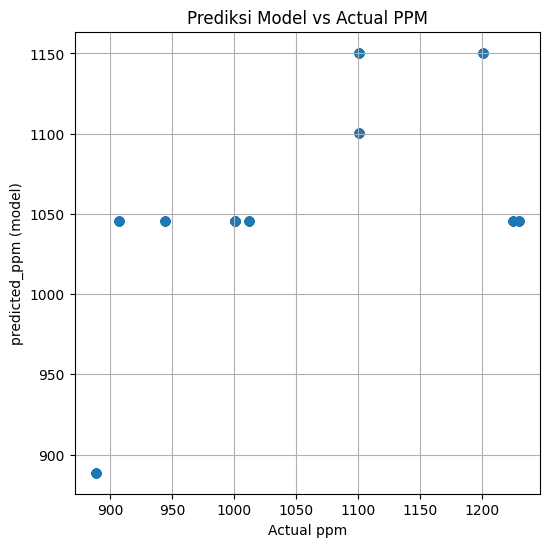

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(df['ppm'], df['predicted_ppm'], alpha=0.6)
plt.xlabel('Actual ppm')
plt.ylabel('predicted_ppm (model)')
plt.title('Prediksi Model vs Actual PPM')
plt.grid(True)
plt.show()

In [26]:
preds_test = reg.predict(X_test_scaled)

In [27]:
df_test = X_test.copy()
df_test['ppm_cluster_mean_true'] = y_test
df_test['predicted_ppm'] = preds_test
df_test['residual'] = df_test['ppm_cluster_mean_true'] - df_test['predicted_ppm']

In [28]:
if 'ppm' in df.columns:
    df_test['actual_ppm'] = df.loc[X_test.index, 'ppm']
if 'cluster' in df.columns:
    df_test['cluster'] = df.loc[X_test.index, 'cluster']

In [29]:
df_test

,ph,water_temp,air_temp,humidity,ppm_cluster_mean_true,predicted_ppm,residual,actual_ppm,cluster
412,6.093200,27.882634,27.970936,72.059246,1150.479329,1150.479329,-3.637979e-12,1100.479329,3
289,6.077200,29.482634,29.792431,76.321417,1045.648150,1045.648150,4.774847e-12,1000.479329,2
76,6.073255,29.152341,30.018621,78.052429,1045.648150,1045.648150,4.774847e-12,907.181192,2
78,6.073255,29.152341,30.018621,78.052429,1045.648150,1045.648150,4.774847e-12,907.181192,2
182,6.069200,28.235678,27.935678,84.443595,1045.538721,1045.538721,-1.818989e-12,1012.481329,0
...,...,...,...,...,...,...,...,...,...
433,6.093200,27.882634,27.970936,72.059246,1150.479329,1150.479329,-3.637979e-12,1100.479329,3
46,6.066393,28.264710,31.636839,70.785572,888.677043,888.677043,2.046363e-12,888.677043,1
93,6.073255,29.152341,30.018621,78.052429,1045.648150,1045.648150,4.774847e-12,907.181192,2
265,6.078200,29.382634,27.111194,88.343120,1045.538721,1045.538721,-1.818989e-12,1000.479329,0


In [30]:
output_dir = 'models'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [31]:
df_test.to_excel(os.path.join(output_dir, 'pakcoy_model_sensor_test_results.xlsx'), index=False)

In [32]:
preds_train = reg.predict(X_train_scaled)
mae_train = mean_absolute_error(y_train, preds_train)
mse_train = mean_squared_error(y_train, preds_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, preds_train)

In [33]:
mae_test = mean_absolute_error(y_test, preds_test)
mse_test = mean_squared_error(y_test, preds_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, preds_test)

In [34]:
metrics = pd.DataFrame({
    'MAE': [mae_train, mae_test],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'R2': [r2_train, r2_test]
}, index=['train','test'])

In [35]:
print("Evaluation metrics:")
display(metrics.round(4))

Evaluation metrics:


,MAE,MSE,RMSE,R2
train,0.0,0.0,0.0,1.0
test,0.0,0.0,0.0,1.0


In [36]:
df_test = df_test.copy()
df_test['predicted_ppm'] = preds_test
df_test['residual'] = df_test['ppm_cluster_mean_true'] - df_test['predicted_ppm']

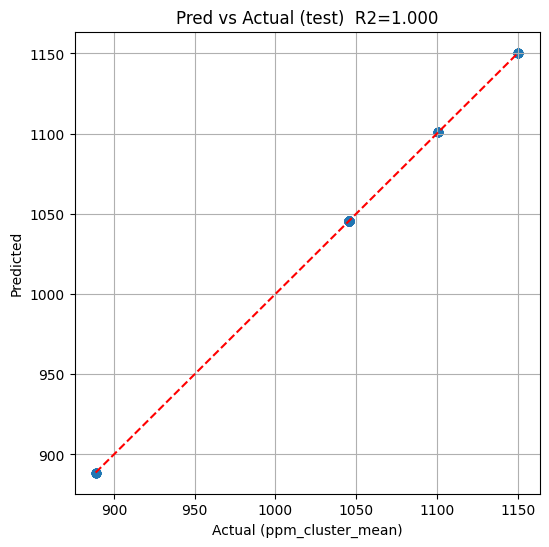

In [37]:
# Plot predicted vs actual (test)
plt.figure(figsize=(6,6))
plt.scatter(df_test['ppm_cluster_mean_true'], df_test['predicted_ppm'], alpha=0.6)
mn = min(df_test['ppm_cluster_mean_true'].min(), df_test['predicted_ppm'].min())
mx = max(df_test['ppm_cluster_mean_true'].max(), df_test['predicted_ppm'].max())
plt.plot([mn,mx],[mn,mx], color='red', linestyle='--')
plt.xlabel('Actual (ppm_cluster_mean)')
plt.ylabel('Predicted')
plt.title(f'Pred vs Actual (test)  R2={r2_test:.3f}')
plt.grid(True)
plt.show()

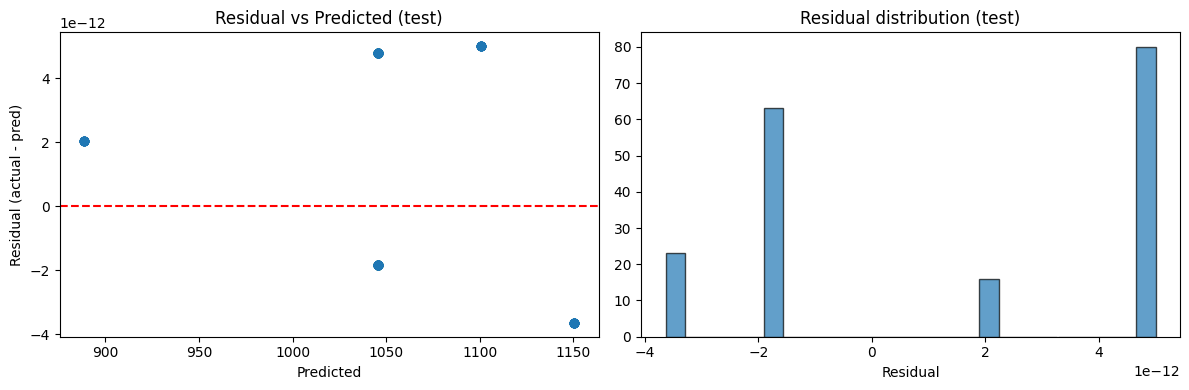

In [38]:
# Residual plot dan histogram
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(df_test['predicted_ppm'], df_test['residual'], alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual (actual - pred)')
plt.title('Residual vs Predicted (test)')

plt.subplot(1,2,2)
plt.hist(df_test['residual'], bins=25, edgecolor='k', alpha=0.7)
plt.xlabel('Residual')
plt.title('Residual distribution (test)')
plt.tight_layout()
plt.show()


Feature importances:


ph            0.6783
humidity      0.2905
air_temp      0.0209
water_temp    0.0103
dtype: float64

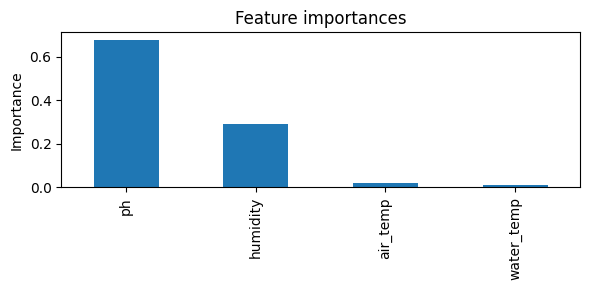

In [39]:
# Feature importances (RandomForest)
if hasattr(reg, 'feature_importances_'):
    feat_imp = pd.Series(reg.feature_importances_, index=features).sort_values(ascending=False)
    print("\nFeature importances:")
    display(feat_imp.round(4))
    plt.figure(figsize=(6,3))
    feat_imp.plot(kind='bar')
    plt.ylabel('Importance')
    plt.title('Feature importances')
    plt.tight_layout()
    plt.show()